C:\Users\Haritha Prithika\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9284 - loss: 0.2447
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9691 - loss: 0.1029
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9784 - loss: 0.0697
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0543
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9866 - loss: 0.0410
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9700 - loss: 0.1026
Test Accuracy: 0.9700000286102295
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted class: 7


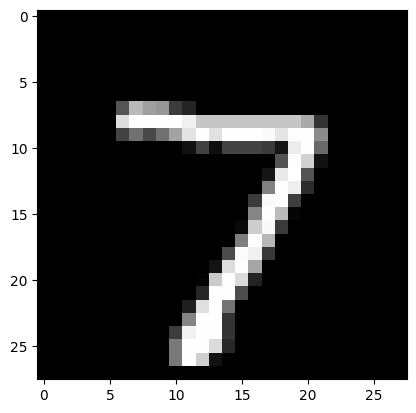

Predicted class: 2


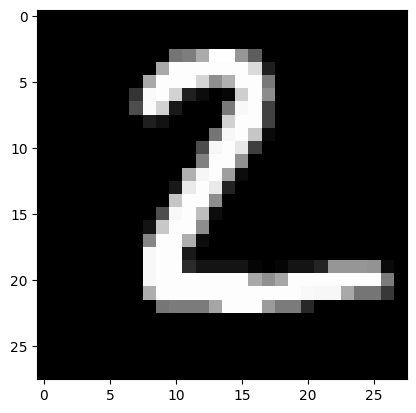

Predicted class: 1


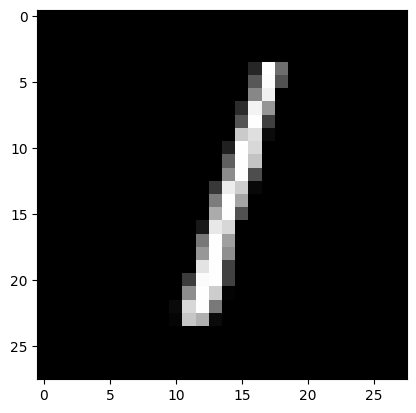

Predicted class: 0


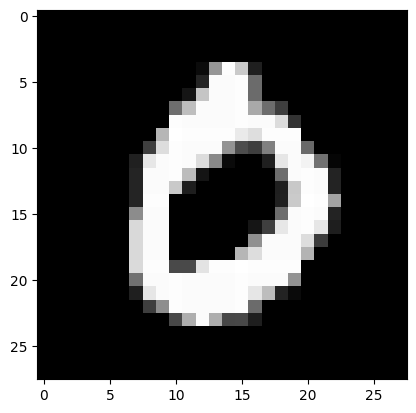

Predicted class: 4


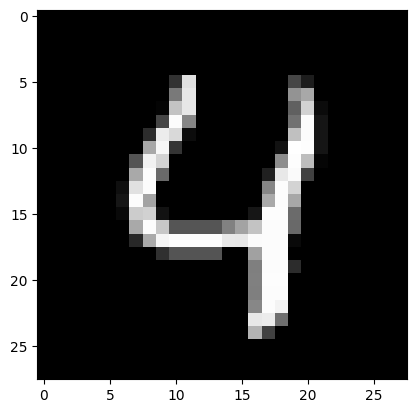

In [1]:
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt 
(X_train,y_train), (X_test,y_test) = keras.datasets.mnist.load_data() 
X_train = X_train / 255.0 
X_test = X_test / 255.0 
X_train = X_train.reshape(-1, 28*28) 
X_test = X_test.reshape(-1, 28*28) 
model = keras.Sequential([ 
keras.layers.Dense(128, activation ='relu', input_shape=(784,)), 
keras.layers.Dense(64, activation='relu'), 
keras.layers.Dense(10, activation='softmax') 
]) 
model.compile( 
optimizer='adam', 
loss='sparse_categorical_crossentropy', 
metrics=['accuracy']) 
model.fit(X_train, y_train, epochs=5) 
test_loss, test_acc = model.evaluate(X_test, y_test) 
print("Test Accuracy:", test_acc) 
predictions = model.predict(X_test[:5]) 
for i in range(5): 
    print("Predicted class:", predictions[i].argmax()) 
    plt.imshow(X_test[i].reshape(28,28), cmap='gray') 
    plt.show() 

Weights: [[-1.46846929 -2.62906917]]
Bias: [19.]


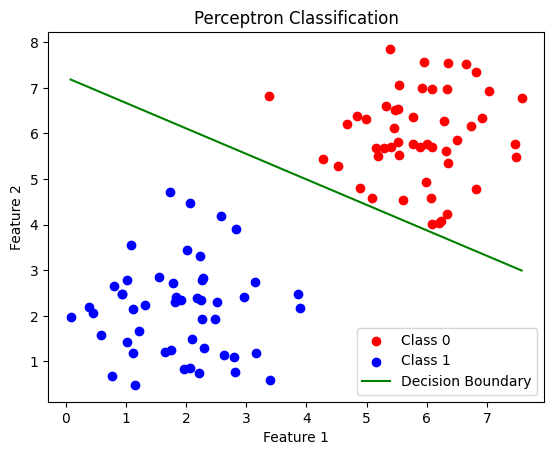

In [2]:
#2) SINGLE PERCEPTRON USING LINEARLY SEPERABLE DATASET 
import numpy as np 
from sklearn.linear_model import Perceptron 
import matplotlib.pyplot as plt 
np.random.seed(42) 
class_0= np.random.randn(50,2)+[6,6] 
class_1= np.random.randn(50,2)+[2,2] 
X=np.vstack((class_0,class_1)) 
y=np.hstack((np.zeros(50), np.ones(50))) 
model = Perceptron(max_iter=1000, tol=1e-3) 
model.fit(X,y) 
print("Weights:",model.coef_) 
print("Bias:", model.intercept_) 
plt.scatter(X[:50,0], X[:50,1], color='red', label='Class 0') 
plt.scatter(X[50:,0], X[50:,1], color='blue', label='Class 1') 
x_vals=np.linspace(X[:,0].min(),X[:,0].max(),100) 
y_vals=-(model.coef_[0][0]*x_vals+model.intercept_[0])/model.coef_[0][1] 
plt.plot(x_vals,y_vals,color='green', label='Decision Boundary') 
plt.legend() 
plt.xlabel("Feature 1") 
plt.ylabel("Feature 2") 
plt.title("Perceptron Classification") 
plt.show()

In [3]:
#3.Backpropagation using Artificial Neural Network 
import numpy as np 
sig = lambda x: 1/(1+np.exp(-x)) 
dsig = lambda x: x*(1-x) 
X = np.array([[0,0], [0,1], [1,0], [1,1]]) 
y = np.array([[0],[1],[1],[0]]) 
np.random.seed(1) 
W1 = np.random.randn(2,4) 
W2 = np.random.randn(4,1) 
lr = 0.1 
for i in range(5000): 
    h = sig(X @ W1) 
    o = sig(h @ W2) 
    d2 = (y - o) * dsig(o) 
    d1 = d2 @ W2.T * dsig(h) 
    W2 += h.T @ d2 * lr 
    W1 += X.T @ d1 * lr 
    if i % 1000 == 0: 
        print(f'Epoch {i}, Loss: {np.mean((y-o)**2):.6f}') 
print("\nFinal Predictions:") 
print(o.round(3)) 


Epoch 0, Loss: 0.264921
Epoch 1000, Loss: 0.203678
Epoch 2000, Loss: 0.149920
Epoch 3000, Loss: 0.071346
Epoch 4000, Loss: 0.033033

Final Predictions:
[[0.143]
 [0.874]
 [0.859]
 [0.149]]


In [4]:
#4 classify digit using deep feed forward NN 
import tensorflow as tf 
import numpy as np 
from tensorflow import keras 
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import mnist 
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense,Flatten 
(x_train, y_train), (x_test, y_test) = mnist.load_data() 
x_train, x_test = x_train/255.0, x_test/255.0 
y_train, y_test = to_categorical(y_train), to_categorical(y_test) 
model = Sequential([ 
Flatten(input_shape=(28,28)), 
Dense(128, activation='relu'), 
Dense(64, activation='relu'), 
Dense(10, activation='softmax') 
]) 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) 
model.fit(x_train, y_train, epochs=3, verbose=0) 
loss, acc = model.evaluate(x_test, y_test, verbose=0) 
pred = model.predict(x_test[:5]).argmax(axis=1) 
print("\n OUTPUT") 
print("Test Accuracy:", acc) 
print("Predicted Classes:", pred) 
print("Actual Classes", np.argmax(y_test[:5], axis=1)) 

C:\Users\Haritha Prithika\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

 OUTPUT
Test Accuracy: 0.9736999869346619
Predicted Classes: [7 2 1 0 4]
Actual Classes [7 2 1 0 4]


In [5]:
# 5.Implementation of Convolutional Neural Network (CNN) 
import numpy as np 
from tensorflow.keras.datasets import mnist 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense 
(x_train, y_train), (x_test, y_test) = mnist.load_data() 
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0 
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0 
model = Sequential([ 
Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), 
MaxPooling2D((2, 2)), 
Conv2D(64, (3, 3), activation='relu'), 
MaxPooling2D((2, 2)), 
Flatten(), 
Dense(64, activation='relu'), 
Dense(10, activation='softmax') 
]) 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) 
model.fit(x_train, y_train, epochs=2, verbose=0) 
loss, acc = model.evaluate(x_test, y_test, verbose=0) 
pred = model.predict(x_test[:5]).argmax(axis=1) 
print("\n=") 
print("Test Accuracy:", acc) 
print("OUTPUT=") 
print("Predicted Digits:", pred) 
print("Actual Digits:", y_test[:5]) 

C:\Users\Haritha Prithika\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

=
Test Accuracy: 0.9868999719619751
OUTPUT=
Predicted Digits: [7 2 1 0 4]
Actual Digits: [7 2 1 0 4]


In [6]:
# 6. RNN to Generate a Sequence and Predict Next Number 
import numpy as np 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN, Dense 
X = np.array([[1,2,3,4,5]]) 
y = np.array([6]) 
X = X.reshape((1,5,1)) 
model = Sequential() 
model.add(SimpleRNN(10, activation='relu', input_shape= (5,1))) 
model.add(Dense(1)) 
model.compile(optimizer='adam', loss='mse') 
model.fit(X, y, epochs=300, verbose=0) 
print("Predicted next number:", model.predict(X))

C:\Users\Haritha Prithika\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Predicted next number: [[6.000003]]


In [7]:
# 7. Transfer Learning using Inbuilt Dataset 
from tensorflow.keras.applications import MobileNetV2 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Flatten 
from tensorflow.keras.datasets import cifar10 
(x_train, y_train), (x_test, y_test) = cifar10.load_data() 
base_model = MobileNetV2(weights='imagenet',include_top=False, input_shape=(32,32,3)) 
base_model.trainable = False 
model = Sequential([base_model,Flatten(),Dense(10, activation='softmax')]) 
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy']) 
model.fit(x_train, y_train, epochs=1) 

C:\Users\Haritha Prithika\AppData\Local\Temp\ipykernel_20812\1952396433.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet',include_top=False, input_shape=(32,32,3))


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 42ms/step - accuracy: 0.1942 - loss: 2.1817


In [8]:
# 8. Autoencoder for Image Reconstruction 
from tensorflow.keras.datasets import mnist 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Flatten, Reshape 
(x_train, _), (x_test, _) = mnist.load_data() 
x_train = x_train/255.0 
x_test = x_test/255.0 
model = Sequential([Flatten(input_shape=(28, 28)),Dense(64, activation='relu'),Dense(784, 
activation='sigmoid'),Reshape((28, 28)) ]) 
model.compile(optimizer='adam', loss='binary_crossentropy') 
model.fit(x_train, x_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1367
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0833
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0772


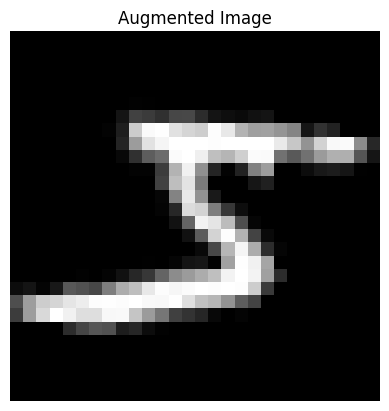

In [9]:
# 9 Data Augmentation using Inbuilt Dataset 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.datasets import mnist 
import numpy as np 
import matplotlib.pyplot as plt 
(x_train, _), (_, _) = mnist.load_data() 
x_train = x_train.reshape(-1, 28, 28, 1) 
datagen = ImageDataGenerator(rotation_range=20, zoom_range=0.2) 
for batch in datagen.flow(x_train[:1], batch_size=1): 
    plt.imshow(batch[0].reshape(28, 28), cmap='gray') 
    plt.title("Augmented Image") 
    plt.axis('off') 
    plt.show() 
    break 

In [10]:
#10 LeNet5 CNN 
from tensorflow.keras.datasets import mnist 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense 
(x_train,y_train), (x_test,y_test) = mnist.load_data() 
x_train=x_train.reshape(-1,28,28,1)/255.0 
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0 
model= Sequential([ 
Conv2D(6, kernel_size=5, activation='relu', input_shape=(28,28,1)), 
AveragePooling2D(pool_size=(2, 2)), 
Conv2D(16, kernel_size=5, activation='relu'), 
AveragePooling2D(pool_size=(2, 2)), 
Flatten(),Dense(120, activation='relu'), Dense(10, activation='softmax')]) 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) 
model.fit(x_train, y_train, epochs=1, validation_data=(x_test, y_test)) 
test_loss, test_acc = model.evaluate(x_test, y_test) 
print("Test Accuracy:", test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9356 - loss: 0.2160 - val_accuracy: 0.9740 - val_loss: 0.0787
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9740 - loss: 0.0787
Test Accuracy: 0.9739999771118164


In [11]:
# 11 Hyper parameter tuning 
import numpy as np 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.optimizers import Adam 
from sklearn.model_selection import train_test_split 
import tensorflow as tf 
tf.compat.v1.enable_eager_execution() 
x = np.array([[1], [2], [3], [4], [5], [6], [7], [8]]) 
y = np.array([2,4,6,8,10,12,14,16]) 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42) 
learning_rates = [0.1, 0.01, 0.001] # Added missing '=' here 
for lr in learning_rates: 
    print("\nTraining with Learning Rate =", lr) 
    model = Sequential() 
    model.add(Dense(8, activation='relu', input_shape=(1,))) # Added missing '=' here 
    model.add(Dense(1)) 
    optimizer = Adam(learning_rate=lr) 
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae']) 
    model.fit(X_train, y_train, epochs=100, verbose=0) 
    loss, mae = model.evaluate(X_test, y_test, verbose=0) 
    print("Test MAE:", mae)



Training with Learning Rate = 0.1


C:\Users\Haritha Prithika\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test MAE: 0.020987749099731445

Training with Learning Rate = 0.01
Test MAE: 0.4371316432952881

Training with Learning Rate = 0.001
Test MAE: 4.916367053985596


In [12]:
#12 save and load neural network 
import numpy as np 
from tensorflow.keras.models import Sequential, load_model 
from tensorflow.keras.layers import Dense 
import tensorflow as tf 
X = np.array([[1], [2], [3], [4], [5]]) 
y= np.array([2,4,6,8,10]) 
model =Sequential() 
model.add(Dense (8, activation= 'relu', input_shape=(1,))) 
model.add(Dense(1)) 
model.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError()) 
model.fit(X, y, epochs=100, verbose=0) 
model.save("linear_model.h5") 
print("Model saved successfully") 
loaded_model= load_model("linear_model.h5") 
prediction =loaded_model.predict(np.array([[6]])) 
print("Prediction for input 6:", prediction) 

Model saved successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction for input 6: [[1.7531606]]


In [13]:
#13. GAN to Generate Images 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
import numpy as np 
generator = Sequential([ 
Dense(16, activation='relu', input_shape=(10,)), 
Dense(784, activation='sigmoid')]) 
noise = np.random.normal(0, 1, (1, 10)) # Added missing '=' sign 
generated_image = generator.predict(noise) 
print("Generated image shape:", generated_image.shape) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Generated image shape: (1, 784)


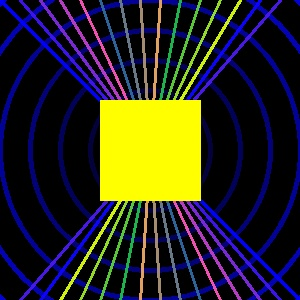

In [14]:
# 14 unique image using openCV and numpy 
# !pip install opencv-python 
import cv2 
import numpy as np 
from IPython.display import display, Image 
height, width = 300, 300 
img = np.zeros((height, width, 3), dtype=np.uint8) 
for i in range(0, height, 30): 
    color = (i % 256, (1*2) % 256, (1*3) % 256) 
    cv2.circle(img, (width//2, height//2), i, color, 3) 
for i in range(0, width, 20): 
    cv2.line(img, (i, 0), (width-i, height), (255-i% 256, i% 256, (i*3) % 256), 2) 
cv2.rectangle(img, (100, 100), (200, 200), (0,255, 255), -1) 
cv2.imwrite("unique_image.jpg", img) 
display(Image(filename="unique_image.jpg"))

In [15]:
# 15) Predict next number using RNN 
import numpy as np 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN, Dense 
# Example: sequence [0,1,2,3,4,5,...), predict next number 
x_train = np.array([[0, 1, 2], [1, 2, 3], [2, 3, 4], [3, 4, 5]], dtype=float) 
y_train = np.array ([3, 4, 5, 6], dtype=float) 
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1)) 
model = Sequential() 
model.add(SimpleRNN (10, activation ='relu', input_shape=(3, 1))) 
model.add(Dense (1)) # Output Layer 
model.compile(optimizer='adam', loss='mse') 
model.fit(x_train, y_train, epochs=200, verbose=0) 
test_input = np.array([4, 5, 6]).reshape((1, 3, 1)) 
predicted = model.predict(test_input, verbose=0) 
print("Next number prediction:", predicted[0][0]) 

Next number prediction: 5.817518
